In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(6983.5), np.float64(4659.5), np.float64(-0.5))

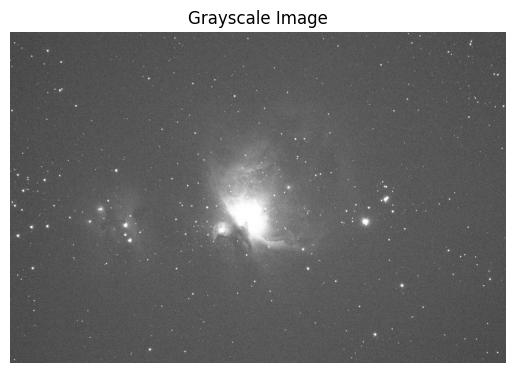

In [4]:
img = cv2.imread("Images/regular_01.jpg", cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

In [7]:
print("dtype:", img.dtype)
print("min:", img.min())
print("max:", img.max())

dtype: uint8
min: 0
max: 255


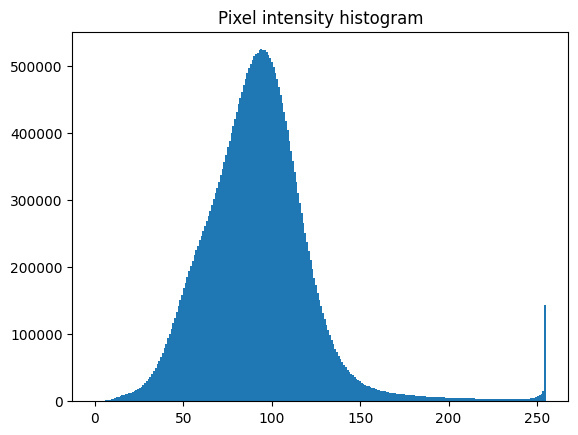

In [5]:
plt.hist(img.ravel(), bins=256)
plt.title("Pixel intensity histogram")
plt.show()

(np.float64(-0.5), np.float64(6983.5), np.float64(4659.5), np.float64(-0.5))

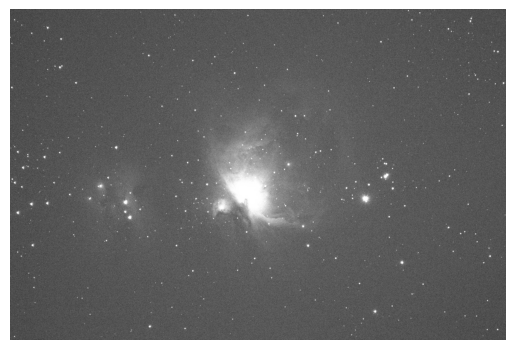

In [6]:
plt.imshow(img, cmap="gray", vmin=img.min(), vmax=img.max())
plt.axis("off")

(np.float64(-0.5), np.float64(6983.5), np.float64(4659.5), np.float64(-0.5))

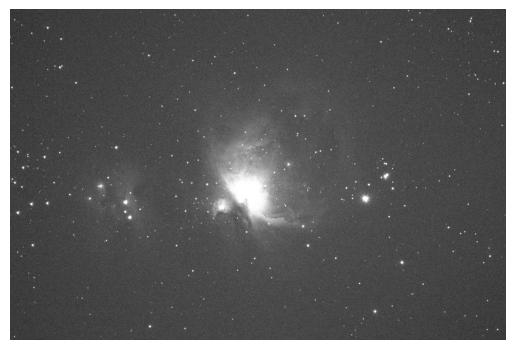

In [11]:
# noise reduction
blur = cv2.GaussianBlur(img, (5,5), 0)

plt.imshow(blur, cmap="gray")
plt.axis("off")

(np.float64(-0.5), np.float64(6983.5), np.float64(4659.5), np.float64(-0.5))

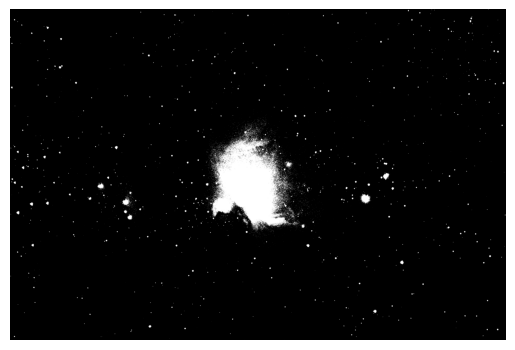

In [13]:
# threshold stars
_, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(thresh, cmap="gray")
plt.axis("off")

In [ ]:
# find contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print("Contours detected:", len(contours))

[[[3862 4659]]]


In [17]:
def compute_circularity(contour):
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)

    if perimeter == 0:
        return 0

    circularity = 4 * np.pi * area / (perimeter ** 2)
    return circularity

In [31]:
circularities = []
valid_contours = []

for c in contours:

    area = cv2.contourArea(c)

    # ignore tiny blobs
    if area < 5 or area > 150:
        continue

    circ = compute_circularity(c)

    if circ < 0.2:
        continue

    circularities.append(circ)
    valid_contours.append(c)

if len(circularities) == 0:
    print('FAILED: No contours found')

print(np.mean(circularities))

0.56638066710047


(np.float64(-0.5), np.float64(6983.5), np.float64(4659.5), np.float64(-0.5))

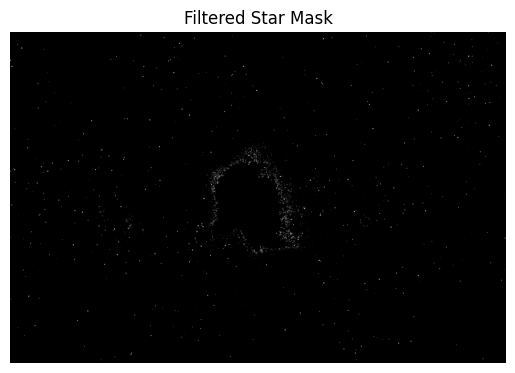

In [32]:
filtered_mask = np.zeros_like(thresh)
cv2.drawContours(filtered_mask, valid_contours, -1, 255, -1)

plt.imshow(filtered_mask, cmap="gray")
plt.title("Filtered Star Mask")
plt.axis("off")

In [33]:
areas = []
circularities = []

for c in contours:

    area = cv2.contourArea(c)

    if area < 1:
        continue

    circ = compute_circularity(c)

    areas.append(area)
    circularities.append(circ)

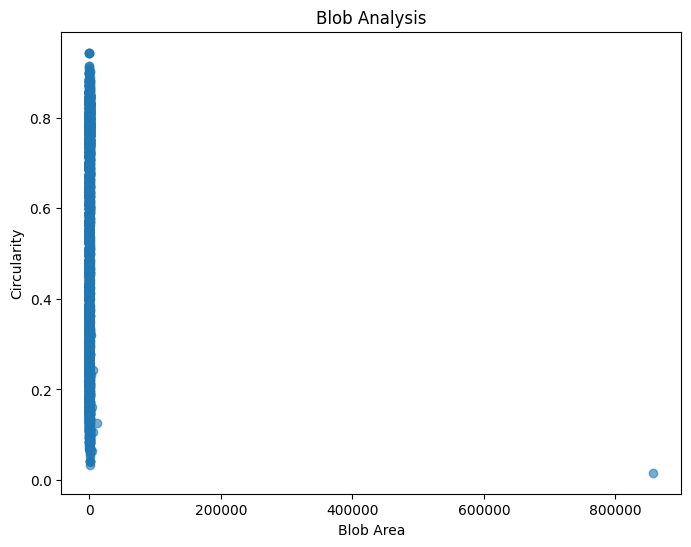

In [34]:
plt.figure(figsize=(8,6))

plt.scatter(areas, circularities, alpha=0.6)

plt.xlabel("Blob Area")
plt.ylabel("Circularity")
plt.title("Blob Analysis")

plt.show()

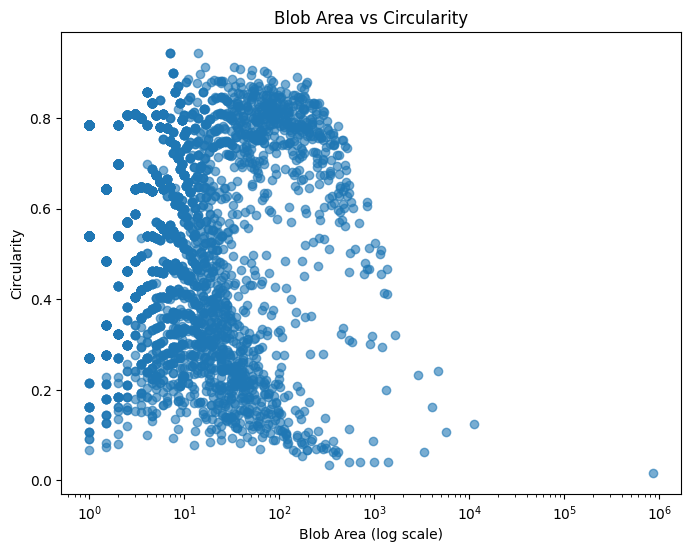

In [35]:
plt.figure(figsize=(8,6))

plt.scatter(areas, circularities, alpha=0.6)

plt.xscale("log")

plt.xlabel("Blob Area (log scale)")
plt.ylabel("Circularity")
plt.title("Blob Area vs Circularity")

plt.show()

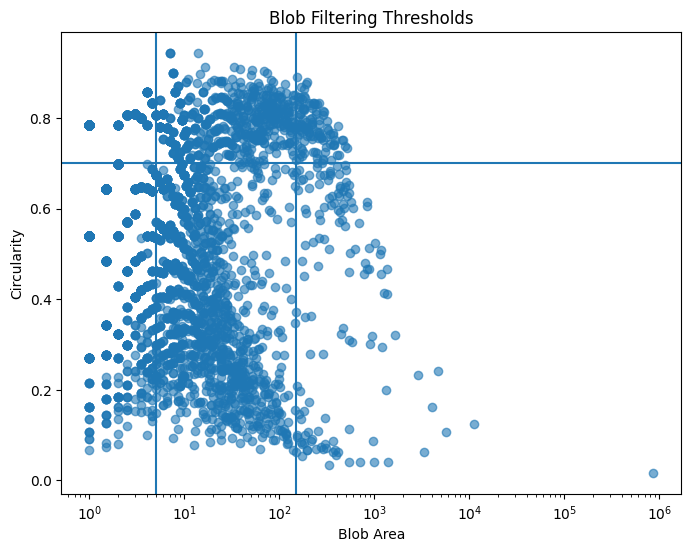

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(areas, circularities, alpha=0.6)

plt.xscale("log")

plt.axvline(5)
plt.axvline(150)

plt.axhline(0.7)

plt.xlabel("Blob Area")
plt.ylabel("Circularity")

plt.title("Blob Filtering Thresholds")

plt.show()

In [37]:
good_area = []
good_circ = []

bad_area = []
bad_circ = []

for a,c in zip(areas,circularities):

    if a < 5 or a > 150 or c < 0.7:
        bad_area.append(a)
        bad_circ.append(c)
    else:
        good_area.append(a)
        good_circ.append(c)

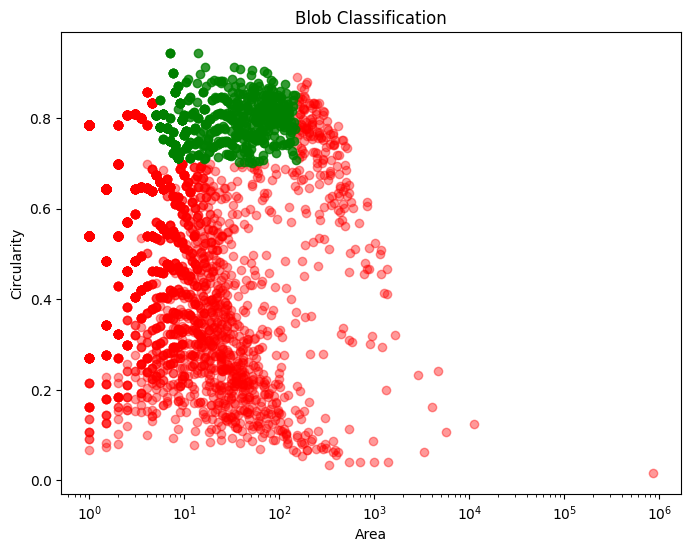

In [38]:
plt.figure(figsize=(8,6))

plt.scatter(bad_area, bad_circ, color="red", alpha=0.4)
plt.scatter(good_area, good_circ, color="green", alpha=0.8)

plt.xscale("log")

plt.xlabel("Area")
plt.ylabel("Circularity")

plt.title("Blob Classification")

plt.show()